   MÉTRICAS DEL ÁRBOL DE DECISIÓN (BANK CHURN)
Accuracy General: 0.8573

Reporte de Clasificación:
              precision    recall  f1-score   support

    Se Queda       0.86      0.98      0.92      2416
       Se Va       0.79      0.36      0.50       584

    accuracy                           0.86      3000
   macro avg       0.83      0.67      0.71      3000
weighted avg       0.85      0.86      0.84      3000


   MÉTRICAS DE SUPPORT VECTOR MACHINE (SVM)
Accuracy General: 0.8610

Reporte de Clasificación:
              precision    recall  f1-score   support

    Se Queda       0.87      0.98      0.92      2416
       Se Va       0.80      0.38      0.52       584

    accuracy                           0.86      3000
   macro avg       0.83      0.68      0.72      3000
weighted avg       0.85      0.86      0.84      3000



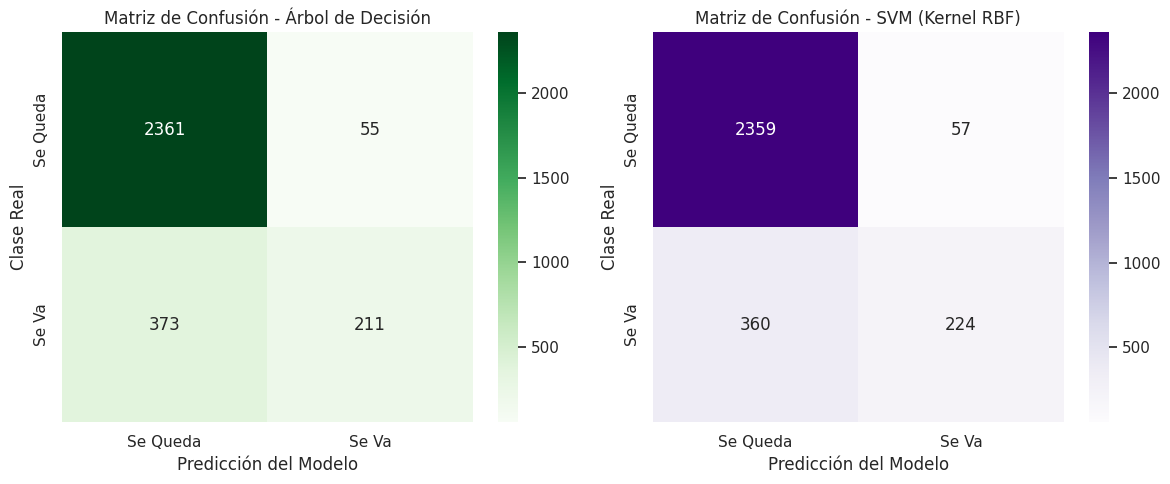

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


sns.set_theme(style="whitegrid")
df = pd.read_csv('archivos_semana_6/ClientDataset.csv')
df.drop(columns=["RowNumber", "CustomerId", "Surname"], inplace=True)
df.dropna(inplace=True)

# Transformación de variables categóricas (Geography, Gender) a numéricas binarias
df_encoded = pd.get_dummies(df, columns=["Geography", "Gender"], drop_first=True, dtype=int)

# Separación de características "predictoras" (X) y variable objetivo (y = Exited)
X = df_encoded.drop(columns=["Exited"])
y = df_encoded["Exited"]

# Partición de datos (Train / Test Split 70/30)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Estandarización
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# MODELO 1: ÁRBOL DE DECISIÓN
tree_model = DecisionTreeClassifier(max_depth=4, random_state=42)
tree_model.fit(X_train_scaled, y_train)
y_pred_tree = tree_model.predict(X_test_scaled)

print("==============================================================================")
print("   MÉTRICAS DEL ÁRBOL DE DECISIÓN (BANK CHURN)")
print("==============================================================================")
print(f"Accuracy General: {accuracy_score(y_test, y_pred_tree):.4f}")
print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred_tree, target_names=["Se Queda", "Se Va"]))

# MODELO 2: SUPPORT VECTOR MACHINE (SVM)
svm_model = SVC(kernel='rbf', random_state=42)
svm_model.fit(X_train_scaled, y_train)
y_pred_svm = svm_model.predict(X_test_scaled)

print("\n==============================================================================")
print("   MÉTRICAS DE SUPPORT VECTOR MACHINE (SVM)")
print("==============================================================================")
print(f"Accuracy General: {accuracy_score(y_test, y_pred_svm):.4f}")
print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred_svm, target_names=["Se Queda", "Se Va"]))

# 6. GENERACIÓN Y GUARDADO DE MATRICES DE CONFUSIÓN VISUALES
cm_tree = confusion_matrix(y_test, y_pred_tree)
cm_svm = confusion_matrix(y_test, y_pred_svm)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Matriz del Árbol de Decisión
sns.heatmap(cm_tree, annot=True, fmt="d", cmap="Greens", ax=axes[0], xticklabels=["Se Queda", "Se Va"], yticklabels=["Se Queda", "Se Va"])
axes[0].set_title("Matriz de Confusión - Árbol de Decisión")
axes[0].set_ylabel("Clase Real")
axes[0].set_xlabel("Predicción del Modelo")

# Matriz de SVM
sns.heatmap(cm_svm, annot=True, fmt="d", cmap="Purples", ax=axes[1], xticklabels=["Se Queda", "Se Va"], yticklabels=["Se Queda", "Se Va"])
axes[1].set_title("Matriz de Confusión - SVM (Kernel RBF)")
axes[1].set_ylabel("Clase Real")
axes[1].set_xlabel("Predicción del Modelo")

plt.tight_layout()
plt.show()

### Las Métricas 

| Métrica | Árbol de Decisión | SVM (Kernel RBF) |
| :--- | :---: | :---: |
| **Accuracy** (Exactitud General) | **85.73%** | **86.10%** | 
| **Precision** (Precisión Clase 1) | **79.32%** | **79.72%** |
| **Recall** (Sensibilidad Clase 1) | **36.13%** | **38.36%** | 
| **Falsos Negativos** (FN) | **373** clientes | **360** clientes | 
| **Falsos Positivos** (FP) | **55** clientes | **57** clientes | 

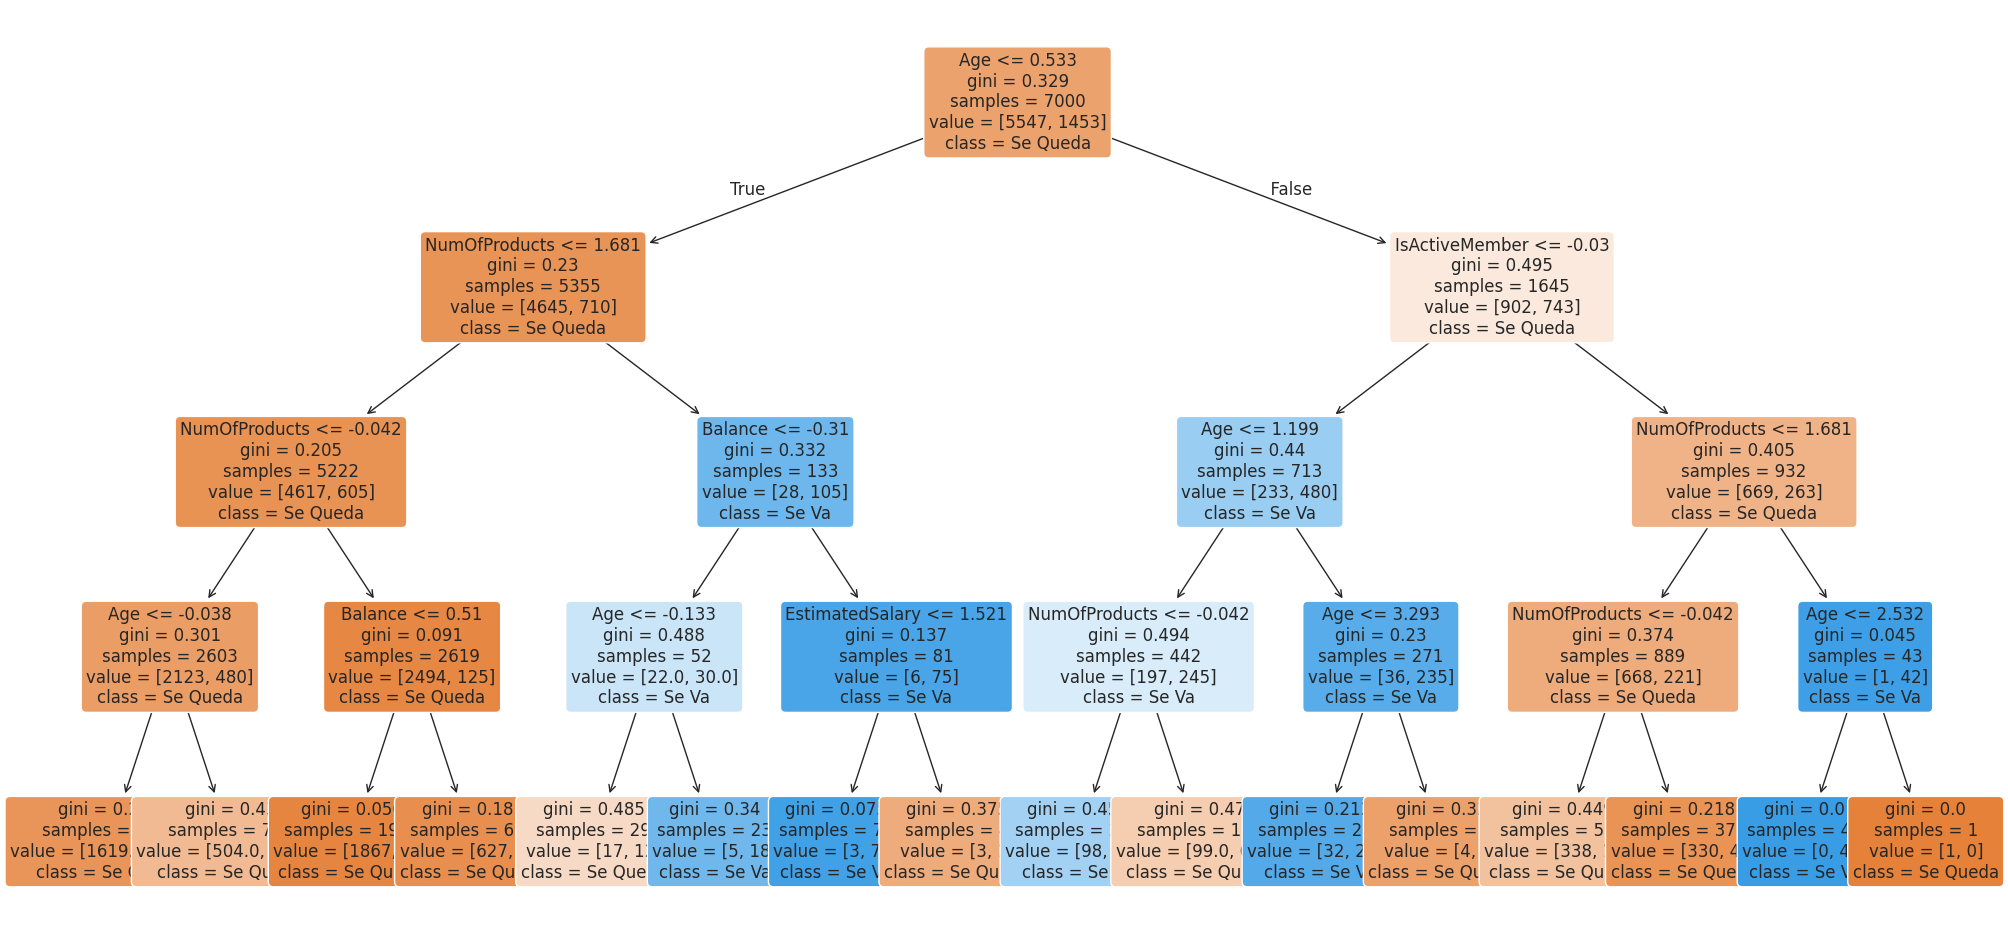

In [ ]:
from sklearn.tree import plot_tree

# Configuramos un tamaño de figura grande para que las letras sean legibles
plt.figure(figsize=(25, 12))

# Graficamos el árbol de decisión
plot_tree(
    tree_model,
    feature_names=X.columns,  # Muestra los nombres reales de las columnas (Age, Balance, etc.)
    class_names=["Se Queda", "Se Va"],  # Traduce el 0 y 1 a etiquetas de negocio
    filled=True,  # Pinta los nodos (el color indica hacia qué clase se inclina)
    rounded=True,  # Redondea las cajas para que quede más estético
    fontsize=12,  # Tamaño de la fuente de las preguntas
)

plt.savefig("estructura_arbol.png", dpi=300, bbox_inches="tight")
plt.show()